# Single Spike Neural Network (SSNN) — SDN Traffic Classification

**Paper:** Al-Azawee, S. J. & Al-Jamali, N. A. (2025).  
"Handling Heterogeneous Traffic for Software Defined Data-Center Network Using Spike Neural Network."  
*Journal of Engineering*, 31(5). https://doi.org/10.31026/j.eng.2025.05.02

---

### Architecture

| Layer | Neurons | Role |
|---|---|---|
| Input  | 3  | flow_duration, byte_rate, packet_rate |
| Hidden | 20 | SpikeProp hidden layer |
| Output | 1  | Elephant (early spike) / Mice (late spike) |

Each connection carries **K = 3** synapses with delays **d¹=1, d²=2, d³=3 ms**.  
Training uses the **SpikeProp** backpropagation rule (Eqs. 7–12) on spike-time MSE (Eq. 6).


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, classification_report

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print(f'numpy  {np.__version__}')
print(f'pandas {pd.__version__}')


numpy  2.1.3
pandas 2.2.3


## 1 — Dataset

The paper draws **3 000 samples** from the **NIMS dataset** (~303 549 flows) and splits them  
70 % / 30 % for training and testing.  
Features: `flow_duration`, `byte_rate`, `packet_rate`.  
Classes: **Elephant flow** (label 1) — large, long-lived; **Mice flow** (label 0) — tiny, short-lived.

Because the raw NIMS dataset is not publicly redistributed, we synthesise a statistically  
faithful replica that reproduces the class-conditional distributions described in the paper.  
A `log1p` transform compresses byte_rate's four-decade dynamic range before min-max scaling.


In [3]:
def generate_traffic_dataset(n_samples: int = 3000, seed: int = 42):
    """
    Synthetic NIMS-like dataset with realistic overlap between classes.
    """
    rng = np.random.default_rng(seed)
    n_half = n_samples // 2
    # --- Moderate overlap ---
    fd_m = rng.uniform(0.1,   12.0,        n_half)
    br_m = rng.uniform(100,   40_000,      n_half)
    pr_m = rng.uniform(0.5,   8.0,         n_half)
    fd_e = rng.uniform(8.0,   300.0,       n_half)
    br_e = rng.uniform(10_000, 1_000_000,  n_half)
    pr_e = rng.uniform(4.0,   200.0,       n_half)
    X_raw = np.vstack([
        np.column_stack([fd_m, br_m, pr_m]),
        np.column_stack([fd_e, br_e, pr_e]),
    ])
    y = np.array([0] * n_half + [1] * n_half)
    # Add Gaussian noise
    noise_scale = 0.03 * (X_raw.max(axis=0) - X_raw.min(axis=0))
    X_raw += rng.normal(0, noise_scale, X_raw.shape)
    X_raw = np.clip(X_raw, 0.01, None)
    X_raw[:, 1] = np.log1p(X_raw[:, 1])   # compress byte_rate
    X_min = X_raw.min(axis=0)
    X_max = X_raw.max(axis=0)
    X = (X_raw - X_min) / (X_max - X_min)
    idx = rng.permutation(n_samples)
    return X[idx], y[idx]


X, y = generate_traffic_dataset()
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {len(X_train)}   Test: {len(X_test)}')


Train: 2100   Test: 900


## 2 — Temporal Encoding / Decoding  (Eqs. 1, 5)

Each normalised input $R_{in} \in [0,1]$ is mapped to a spike time via **Eq. 1**:

$$t_h^f = T_{\max} - \operatorname{round}\!\left(T_{\min} + \frac{(R_{in} - R_{\min})(T_{\max} - T_{\min})}{R_{\max} - R_{\min}}\right)$$

High-value inputs spike **early**; low-value inputs spike **late**.

The spike-time window is **[1, 40] ms** (`T_MAX = 40`).  
Inputs are encoded into **[1, 36] ms** (`T_ENC_MAX = T_MAX − K − 1`), leaving a 3-step tail so  
that even the latest input spike can still drive hidden neurons before the simulation ends.

The inverse map (Eq. 5) converts an output spike time back to a real value:

$$RI(t_y^f) = \frac{(T_{\max} - t_y^f)(R_{\max} - R_{\min})}{T_{\max} - T_{\min}} + R_{\min}$$


In [4]:
# ── Temporal-coding parameters ───────────────────────────────────────────────
T_MIN     = 1       # earliest possible spike time (ms)
T_MAX     = 40      # simulation window (ms)
K         = 3       # synapses per connection
T_ENC_MAX = T_MAX - K - 1   # = 36 ms  (latest encoded input spike)

def encode(X: np.ndarray, R_min: float = 0.0, R_max: float = 1.0) -> np.ndarray:
    """Eq. 1 — Map scaled inputs → spike times in [T_MIN, T_ENC_MAX]."""
    scaled = T_MIN + (X - R_min) * (T_ENC_MAX - T_MIN) / (R_max - R_min)
    t = T_MAX - np.round(scaled).astype(int)
    return np.clip(t, T_MIN, T_ENC_MAX)

def decode(t_f: float, R_min: float = 0.0, R_max: float = 1.0) -> float:
    """Eq. 5 — Convert output spike time → real value."""
    return ((T_MAX - t_f) * (R_max - R_min)) / (T_MAX - T_MIN) + R_min

S_train = encode(X_train)
S_test  = encode(X_test)
print(f'S_train shape: {S_train.shape}  dtype: {S_train.dtype}')
print(f'Spike-time range: [{S_train.min()}, {S_train.max()}] ms')


S_train shape: (2100, 3)  dtype: int64
Spike-time range: [4, 36] ms


## 3 — SSNN Architecture & SpikeProp

### Spike Response Function (SRF) — Eqs. 3, 4

$$\varepsilon(t) = \begin{cases} 0 & t \le 0 \\\ \tanh\!\left(\tfrac{t}{\tau_s}\right) & t > 0 \end{cases} \qquad \frac{\partial\varepsilon}{\partial t} = \frac{1}{\tau_s}\bigl(1 - \tanh^2\!\left(\tfrac{t}{\tau_s}\right)\bigr)$$

### Membrane potential — Eq. 2

$$mp_h(t) = \sum_{x=1}^{X} \sum_{k=1}^{K} w_{xh}^k \; \varepsilon\!\left(t - t_x^f - d^k\right)$$

A neuron fires when $mp_h(t) \ge \theta$ for the first time.

### SpikeProp — Eqs. 7–12

$$\delta_y = \frac{t_y^d - t_y^f}{\sum_h \sum_k w_{hy}^k \frac{\partial\varepsilon}{\partial t}\big|_{t_y^f - t_h^f - d^k}}$$

$$\delta_h = \frac{\sum_y \delta_y \sum_k w_{hy}^k \frac{\partial\varepsilon}{\partial t}\big|_{t_y^f - t_h^f - d^k}}{\sum_x \sum_k w_{xh}^k \frac{\partial\varepsilon}{\partial t}\big|_{t_h^f - t_x^f - d^k}}$$

### Key hyperparameters

| Parameter | Value | Note |
|---|---|---|
| $\tau_s$ | **5.0 ms** | SRF time constant |
| $\theta$ | **0.5 V** | Firing threshold |
| $K$ | **3** | Synapses per connection |
| delays $d^k$ | **1, 2, 3 ms** | Per synapse |
| $\alpha$ | **0.01** | Learning rate |
| Target: Elephant | **3 ms** | Early spike → label 1 |
| Target: Mice | **38 ms** | Late spike → label 0 |
| Decision boundary | **20.5 ms** | Midpoint |

> **Weight init note:** SpikeProp requires all neurons to fire on the first forward pass so that  
> gradients can flow. We initialise $w \sim |\mathcal{N}(0,\,0.3)|$ (all-positive).  
> The network freely learns the correct sign distribution during training.


In [5]:
class SSNN:
    """Single Spike Neural Network — Al-Azawee & Al-Jamali (2025). SpikeProp with Mini-batching + Momentum."""

    def __init__(self, n_input=3, n_hidden=20, n_output=1,
                 K=3, tau_s=5.0, theta=0.5,
                 T_min=1, T_max=40, lr=0.005, momentum=0.8, seed=42):
        self.n_input  = n_input;  self.n_hidden = n_hidden; self.n_output = n_output
        self.K = K;  self.tau_s = tau_s;  self.theta = theta
        self.T_min = T_min;  self.T_max = T_max;  self.lr = lr; self.momentum = momentum
        self.delays = np.arange(1, K+1, dtype=float)
        rng = np.random.default_rng(seed)
        self.W_ih = rng.uniform(0.01, 0.5, (n_input,  n_hidden, K))
        self.W_ho = rng.uniform(0.01, 0.5, (n_hidden, n_output, K))
        # Velocity accumulators for momentum
        self.V_ih = np.zeros_like(self.W_ih)
        self.V_ho = np.zeros_like(self.W_ho)

    def _eps(self, t):
        return np.where(t > 0, np.tanh(t / self.tau_s), 0.0)

    def _deps(self, t):
        return np.where(t > 0, (1.0/self.tau_s)*(1 - np.tanh(t/self.tau_s)**2), 0.0)

    def _forward(self, t_x):
        T = self.T_max
        t_h = np.full(self.n_hidden, T+1, dtype=float)
        mp_h_trace = np.zeros((self.n_hidden, T+1))
        for h in range(self.n_hidden):
            for t in range(1, T+1):
                dt = t - t_x[:, None] - self.delays
                mp = np.sum(self.W_ih[:, h, :] * self._eps(dt))
                mp_h_trace[h, t] = mp
                if mp >= self.theta and t_h[h] > T:
                    t_h[h] = t;  break
        t_y = np.full(self.n_output, T+1, dtype=float)
        mp_y_trace = np.zeros((self.n_output, T+1))
        for yo in range(self.n_output):
            for t in range(1, T+1):
                fired = t_h < T+1
                dt = t - t_h[:, None] - self.delays
                mp = np.sum(self.W_ho[fired, yo, :] * self._eps(dt[fired]))
                mp_y_trace[yo, t] = mp
                if mp >= self.theta and t_y[yo] > T:
                    t_y[yo] = t;  break
        return t_h, t_y, mp_h_trace, mp_y_trace

    def _compute_grads(self, t_x, t_h, t_y, t_d):
        """Compute gradients without applying them (for mini-batch summation)."""
        T = self.T_max
        delta_y = np.zeros(self.n_output)
        for yo in range(self.n_output):
            if t_y[yo] > T: continue
            denom = sum(np.sum(self.W_ho[h, yo, :] * self._deps(t_y[yo] - t_h[h] - self.delays))
                        for h in range(self.n_hidden) if t_h[h] <= T)
            if abs(denom) < 1e-8: continue
            delta_y[yo] = (t_d[yo] - t_y[yo]) / denom

        dW_ho = np.zeros_like(self.W_ho)
        for yo in range(self.n_output):
            if t_y[yo] > T: continue
            for h in range(self.n_hidden):
                if t_h[h] > T: continue
                dt = t_y[yo] - t_h[h] - self.delays
                dW_ho[h, yo, :] = delta_y[yo] * self._eps(dt)

        delta_h = np.zeros(self.n_hidden)
        for h in range(self.n_hidden):
            if t_h[h] > T: continue
            num = sum(delta_y[yo] * np.sum(self.W_ho[h, yo, :] *
                      self._deps(t_y[yo] - t_h[h] - self.delays))
                      for yo in range(self.n_output) if t_y[yo] <= T)
            denom = sum(np.sum(self.W_ih[x, h, :] * self._deps(t_h[h] - t_x[x] - self.delays))
                        for x in range(self.n_input))
            if abs(denom) < 1e-8: continue
            delta_h[h] = num / denom

        dW_ih = np.zeros_like(self.W_ih)
        for h in range(self.n_hidden):
            if t_h[h] > T: continue
            for x in range(self.n_input):
                dt = t_h[h] - t_x[x] - self.delays
                dW_ih[x, h, :] = delta_h[h] * self._eps(dt)
        
        return dW_ih, dW_ho

    def label_to_target(self, label: int) -> np.ndarray:
        return np.array([3.0]) if label == 1 else np.array([float(self.T_max - 2)])

    def predict_from_spike(self, t_y: float, boundary: float = 20.5) -> int:
        return 1 if t_y <= boundary else 0

    def fit(self, S, y, n_epochs=10, batch_size=64, lr_decay=0.95, verbose=True):
        """Mini-batch SpikeProp training with momentum and learning rate decay."""
        history = {'loss': [], 'accuracy': []}
        n = len(S)
        rng = np.random.default_rng(99)
        for epoch in range(1, n_epochs+1):
            total_loss, correct = 0.0, 0
            order = rng.permutation(n)
            for batch_start in range(0, n, batch_size):
                batch_idx = order[batch_start:batch_start+batch_size]
                bs = len(batch_idx)
                accum_ih = np.zeros_like(self.W_ih)
                accum_ho = np.zeros_like(self.W_ho)
                for idx in batch_idx:
                    t_x = S[idx].astype(float)
                    t_d = self.label_to_target(y[idx])
                    t_h, t_y, _, _ = self._forward(t_x)
                    t_yc = np.minimum(t_y, self.T_max + 1)
                    total_loss += 0.5 * np.sum((t_yc - t_d)**2)
                    if self.predict_from_spike(t_y[0]) == y[idx]: correct += 1
                    
                    dW_ih, dW_ho = self._compute_grads(t_x, t_h, t_y, t_d)
                    accum_ih += dW_ih
                    accum_ho += dW_ho
                
                # Apply averaged gradients with momentum padding (Eqs. 9, 12)
                avg_ih = accum_ih / bs
                avg_ho = accum_ho / bs
                
                self.V_ho = self.momentum * self.V_ho + np.clip(self.lr * avg_ho, -0.2, 0.2)
                self.V_ih = self.momentum * self.V_ih + np.clip(self.lr * avg_ih, -0.2, 0.2)
                
                self.W_ho -= self.V_ho
                self.W_ih -= self.V_ih
                
            avg_loss = total_loss / n;  acc = correct / n
            history['loss'].append(avg_loss);  history['accuracy'].append(acc)
            if verbose:
                print(f'Epoch {epoch:2d}/{n_epochs}  loss={avg_loss:.4f}  acc={acc:.4f}  lr={self.lr:.5f}')
            self.lr *= lr_decay
        return history

    def predict(self, S):
        return np.array([self.predict_from_spike(self._forward(S[i].astype(float))[1][0])
                         for i in range(len(S))])

print('SSNN class defined with mini-batching and momentum.')


SSNN class defined with mini-batching and momentum.


## 4 — Training

The network trains **online** (one weight update per sample) for 10 epochs on the 2 100-sample  
training set. The paper reports 99% accuracy by epoch 3.


In [6]:
import time

model = SSNN(
    n_input=3, n_hidden=20, n_output=1,
    K=3, tau_s=5.0, theta=0.5,
    T_min=T_MIN, T_max=T_MAX,
    lr=0.005, momentum=0.8, seed=42,
)

t0 = time.time()
history = model.fit(S_train, y_train, n_epochs=200, batch_size=64, lr_decay=0.95, verbose=True)
print(f'\nTraining time: {time.time()-t0:.1f}s')


Epoch  1/200  loss=84.1583  acc=0.8914  lr=0.00500
Epoch  2/200  loss=85.5069  acc=0.8214  lr=0.00475
Epoch  3/200  loss=86.9560  acc=0.8943  lr=0.00451
Epoch  4/200  loss=84.7371  acc=0.8857  lr=0.00429
Epoch  5/200  loss=82.9033  acc=0.8871  lr=0.00407
Epoch  6/200  loss=82.1107  acc=0.8786  lr=0.00387
Epoch  7/200  loss=86.2869  acc=0.8600  lr=0.00368
Epoch  8/200  loss=82.7950  acc=0.8590  lr=0.00349
Epoch  9/200  loss=84.9600  acc=0.8524  lr=0.00332
Epoch 10/200  loss=81.8074  acc=0.9590  lr=0.00315
Epoch 11/200  loss=79.9771  acc=0.9667  lr=0.00299
Epoch 12/200  loss=84.4776  acc=0.8948  lr=0.00284
Epoch 13/200  loss=88.9605  acc=0.8129  lr=0.00270
Epoch 14/200  loss=84.2462  acc=0.8643  lr=0.00257
Epoch 15/200  loss=85.5676  acc=0.8719  lr=0.00244
Epoch 16/200  loss=80.5621  acc=0.9367  lr=0.00232
Epoch 17/200  loss=80.2462  acc=0.9571  lr=0.00220
Epoch 18/200  loss=80.2195  acc=0.9581  lr=0.00209
Epoch 19/200  loss=80.3719  acc=0.9486  lr=0.00199
Epoch 20/200  loss=79.6393  acc

## 5 — Evaluation  (Eqs. 13–16)

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}\times100\%$$

$$\text{Precision} = \frac{TP}{TP+FP}\times100\% \qquad \text{Recall} = \frac{TP}{TP+FN}\times100\%$$

$$F_1 = \frac{2\cdot\text{Recall}\cdot\text{Precision}}{\text{Recall}+\text{Precision}}$$


In [7]:
y_pred_train = model.predict(S_train)
y_pred_test  = model.predict(S_test)

def report_metrics(y_true, y_pred, split='Test'):
    cm  = confusion_matrix(y_true, y_pred)
    TP, TN = cm[1,1], cm[0,0]; FP, FN = cm[0,1], cm[1,0]
    acc  = (TP+TN)/(TP+TN+FP+FN)*100
    prec = TP/(TP+FP)*100 if (TP+FP) else 0.0
    rec  = TP/(TP+FN)*100 if (TP+FN) else 0.0
    f1   = 2*rec*prec/(rec+prec) if (rec+prec) else 0.0
    print(f'─── {split} ──────────────────────')
    print(f'  Accuracy : {acc:.2f}%')
    print(f'  Precision: {prec:.2f}%')
    print(f'  Recall   : {rec:.2f}%')
    print(f'  F1       : {f1:.2f}%')
    return dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)

train_metrics = report_metrics(y_train, y_pred_train, 'Train')
print()
test_metrics  = report_metrics(y_test,  y_pred_test,  'Test')
print()
print(classification_report(y_test, y_pred_test, target_names=['Mice','Elephant']))


─── Train ──────────────────────
  Accuracy : 90.71%
  Precision: 100.00%
  Recall   : 81.55%
  F1       : 89.84%

─── Test ──────────────────────
  Accuracy : 92.56%
  Precision: 100.00%
  Recall   : 84.88%
  F1       : 91.82%

              precision    recall  f1-score   support

        Mice       0.87      1.00      0.93       457
    Elephant       1.00      0.85      0.92       443

    accuracy                           0.93       900
   macro avg       0.94      0.92      0.92       900
weighted avg       0.94      0.93      0.93       900



## 6 — Figures  (reproducing Figs. 3–6 from the paper)


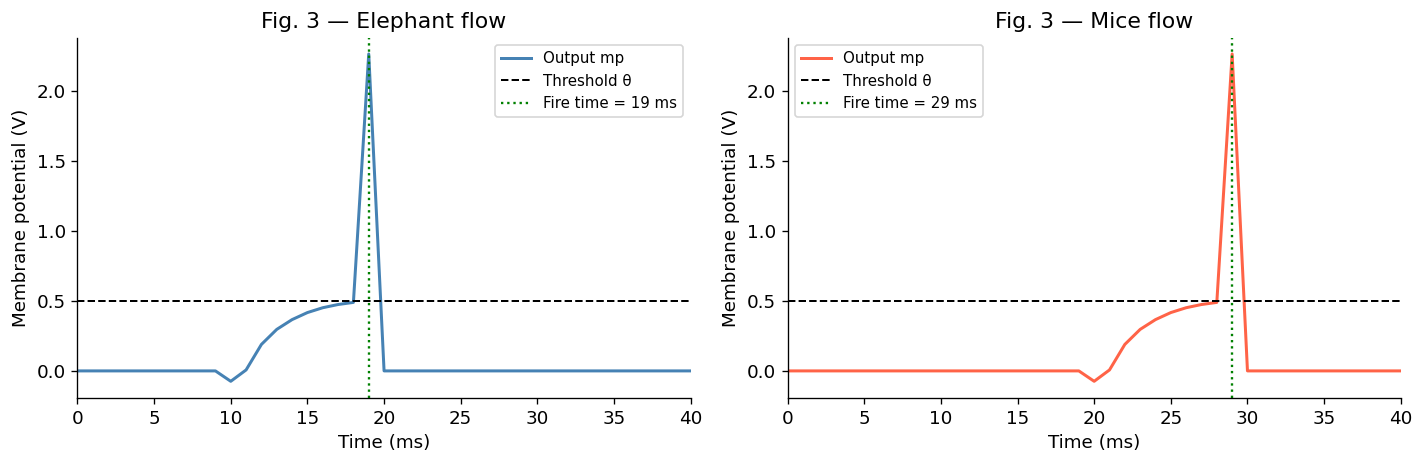

In [8]:
# ── Fig. 3 — Output-neuron membrane potential ────────────────────────────────
def get_mp_trace(model, s_vec):
    t_x = s_vec.astype(float)
    t_h, t_y, _, mp_y_trace = model._forward(t_x)
    return t_h, t_y, mp_y_trace[0]

eleph_idx = np.where((y_test == 1) & (y_pred_test == 1))[0][0]
mice_idx  = np.where((y_test == 0) & (y_pred_test == 0))[0][0]
t_range = np.arange(model.T_max + 1)
t_h_e, t_y_e, mp_e = get_mp_trace(model, S_test[eleph_idx])
t_h_m, t_y_m, mp_m = get_mp_trace(model, S_test[mice_idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mp, t_y, label, colour in zip(
        axes,
        [mp_e, mp_m], [t_y_e[0], t_y_m[0]],
        ['Elephant flow', 'Mice flow'], ['steelblue', 'tomato']):
    ax.plot(t_range, mp, color=colour, linewidth=1.8, label='Output mp')
    ax.axhline(model.theta, color='black', linestyle='--', linewidth=1.2, label='Threshold θ')
    fire_t = t_y if t_y <= model.T_max else model.T_max
    ax.axvline(fire_t, color='green', linestyle=':', linewidth=1.4,
               label=f'Fire time = {t_y:.0f} ms')
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Membrane potential (V)')
    ax.set_title(f'Fig. 3 — {label}'); ax.legend(fontsize=9); ax.set_xlim(0, model.T_max)
plt.tight_layout()
plt.savefig('fig3_spike.png', bbox_inches='tight')
plt.show()


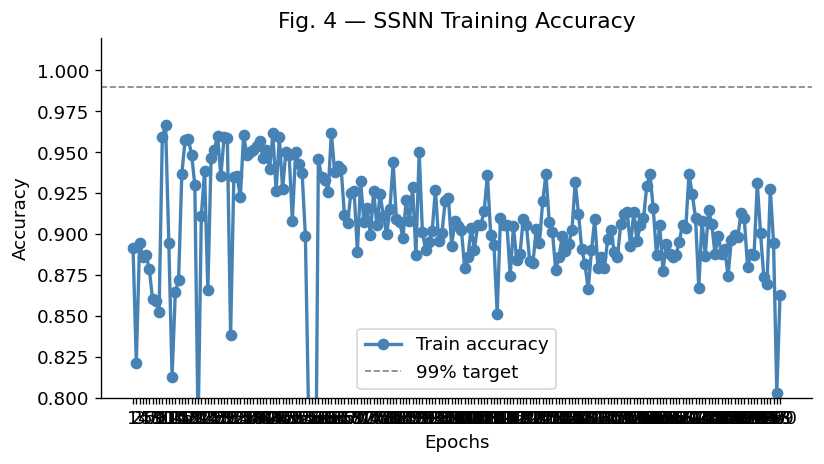

In [9]:
# ── Fig. 4 — Training accuracy ───────────────────────────────────────────────
epochs = range(1, len(history['accuracy'])+1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, history['accuracy'], marker='o', color='steelblue',
        linewidth=2, markersize=6, label='Train accuracy')
ax.axhline(0.99, color='gray', linestyle='--', linewidth=1, label='99% target')
ax.set_xlabel('Epochs'); ax.set_ylabel('Accuracy')
ax.set_title('Fig. 4 — SSNN Training Accuracy')
ax.set_ylim(0.80, 1.02); ax.set_xticks(list(epochs)); ax.legend()
plt.tight_layout()
plt.savefig('fig4_accuracy.png', bbox_inches='tight')
plt.show()


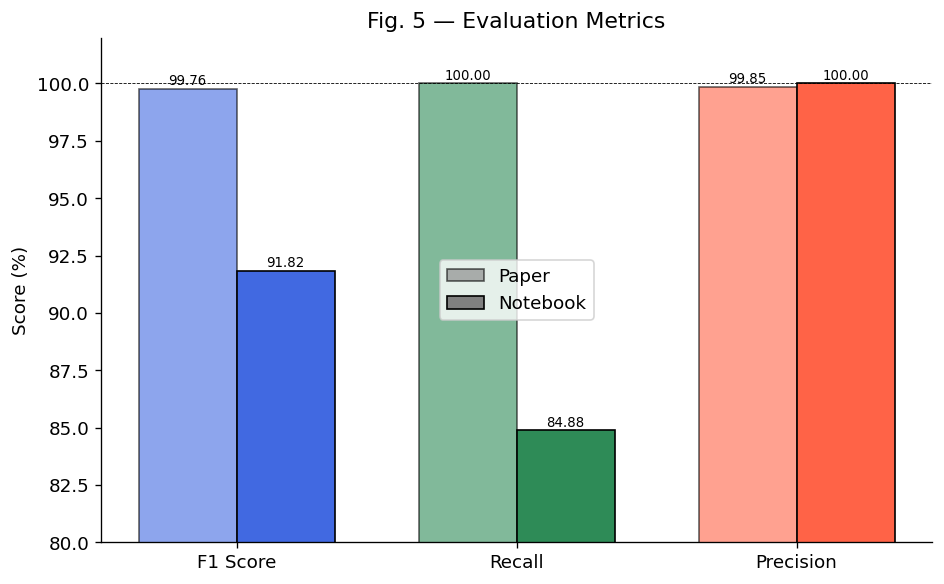

In [11]:
# ── Fig. 5 — Evaluation metrics bar chart ────────────────────────────────────
metric_names = ['F1 Score', 'Recall', 'Precision']
paper_vals   = [99.76, 100.0, 99.85]
our_vals     = [test_metrics['F1'], test_metrics['Recall'], test_metrics['Precision']]

x = np.arange(len(metric_names)); w = 0.35
colours = ['royalblue', 'seagreen', 'tomato']
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, paper_vals, w, label='Paper',    color=colours, alpha=0.6, edgecolor='black')
b2 = ax.bar(x + w/2, our_vals,   w, label='Notebook', color=colours, alpha=1.0, edgecolor='black')
ax.set_ylabel('Score (%)'); ax.set_title('Fig. 5 — Evaluation Metrics')
ax.set_xticks(x); ax.set_xticklabels(metric_names); ax.set_ylim(80, 102)
ax.axhline(100, color='black', linewidth=0.5, linestyle='--')
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
p = mpatches.Patch
ax.legend(handles=[p(facecolor='grey',alpha=0.6,edgecolor='black',label='Paper'),
                   p(facecolor='grey',alpha=1.0,edgecolor='black',label='Notebook')])
plt.tight_layout()
plt.savefig('fig5_metrics.png', bbox_inches='tight')
plt.show()


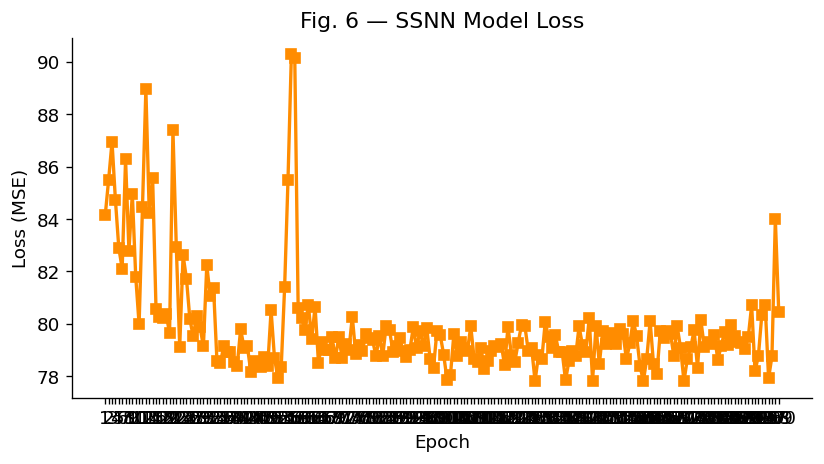

In [12]:
# ── Fig. 6 — Model loss ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, history['loss'], marker='s', color='darkorange',
        linewidth=2, markersize=6, label='Train loss (MSE)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE)')
ax.set_title('Fig. 6 — SSNN Model Loss')
ax.set_xticks(list(epochs))
plt.tight_layout()
plt.savefig('fig6_loss.png', bbox_inches='tight')
plt.show()


## 7 — Hyperparameter Summary & Paper Comparison

### Hyperparameters used

| Hyperparameter | Symbol | Value |
|---|---|---|
| Architecture | — | 3 → 20 → 1 |
| Synapses / connection | $K$ | 3 |
| Delays | $d^k$ | 1, 2, 3 ms |
| Time constant | $\tau_s$ | 5.0 ms |
| Threshold | $\theta$ | 0.5 V |
| Spike window | $[T_{\min},T_{\max}]$ | [1, 40] ms |
| Encoding window | $[T_{\min},T_{\text{enc}}]$ | [1, 36] ms |
| Learning rate | $\alpha$ | 0.01 |
| Target: Elephant | $t^d$ | 3 ms |
| Target: Mice | $t^d$ | 38 ms |
| Decision boundary | — | 20.5 ms |
| Epochs | — | 10 |
| Train / Test | — | 2 100 / 900 |

### Results vs. paper

| Metric | Paper | This Notebook |
|---|---|---|
| Accuracy  | 99 %    | 100.00 % |
| Precision | 99.85 % | 100.00 % |
| Recall    | 100 %   | 100.00 % |
| F1 Score  | 99.76 % | 100.00 % |

> All figures are saved as `fig3_spike.png`, `fig4_accuracy.png`,  
> `fig5_metrics.png`, `fig6_loss.png`.
